In [11]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

In [12]:
# --- 1. CONFIGURATION ---
TRAIN_PATH = 'OneDrive_1_09-04-2026/x_train/'
TEST_PATH = 'OneDrive_1_09-04-2026/x_test/'
Y_TRAIN_FILE = 'OneDrive_1_09-04-2026/y_train_v2.csv'


In [13]:
# --- 2. LOADING LABELS ---
labels_df = pd.read_csv(Y_TRAIN_FILE)

def load_images_from_folder(folder, start_idx, end_idx, is_train=True):
    images = []
    labels = []
    total = end_idx - start_idx + 1

    print(f"--- Load {total} images in {folder} ---")

    for count, i in enumerate(range(start_idx, end_idx + 1)):
        img_name = f"img_{i}.png"
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)

            if is_train:
                target = labels_df.loc[labels_df['id'] == (i - 1), 'target'].values[0]
                labels.append(target)

        if (count + 1) % 500 == 0:
            print(f"Progress : {count + 1} / {total} images loaded...")

    return np.array(images), np.array(labels)


In [14]:
# Loading Train & Testing
X_train, y_train = load_images_from_folder(TRAIN_PATH, 1, 9227, is_train=True)
X_kaggle, _ = load_images_from_folder(TEST_PATH, 9228, 13182, is_train=False)

IMG_H, IMG_W, IMG_C = X_train[0].shape

# Normalisation
X_train = X_train.astype('float32') / 255.0
X_kaggle = X_kaggle.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, num_classes=4)

--- Load 9227 images in OneDrive_1_09-04-2026/x_train/ ---
Progress : 500 / 9227 images loaded...
Progress : 1000 / 9227 images loaded...
Progress : 1500 / 9227 images loaded...
Progress : 2000 / 9227 images loaded...
Progress : 2500 / 9227 images loaded...
Progress : 3000 / 9227 images loaded...
Progress : 3500 / 9227 images loaded...
Progress : 4000 / 9227 images loaded...
Progress : 4500 / 9227 images loaded...
Progress : 5000 / 9227 images loaded...
Progress : 5500 / 9227 images loaded...
Progress : 6000 / 9227 images loaded...
Progress : 6500 / 9227 images loaded...
Progress : 7000 / 9227 images loaded...
Progress : 7500 / 9227 images loaded...
Progress : 8000 / 9227 images loaded...
Progress : 8500 / 9227 images loaded...
Progress : 9000 / 9227 images loaded...
--- Load 3955 images in OneDrive_1_09-04-2026/x_test/ ---
Progress : 500 / 3955 images loaded...
Progress : 1000 / 3955 images loaded...
Progress : 1500 / 3955 images loaded...
Progress : 2000 / 3955 images loaded...
Progr

In [15]:
# --- 3. MODEL ARCHITECTURE (CNN) ---
model = Sequential([
    Input(shape=(IMG_H, IMG_W, IMG_C)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 43, 49, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 21, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6336)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       811,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 831,044 (3.17 MB)

 Trainable params: 831,044 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
# --- 4. TRAINING ---
print("\nTraining begins...")
history = model.fit(X_train, y_train_cat, epochs=30, batch_size=32)


Training begins...
Epoch 1/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6736 - loss: 0.7835
Epoch 2/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7967 - loss: 0.4999
Epoch 3/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8394 - loss: 0.3904
Epoch 4/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8673 - loss: 0.3293
Epoch 5/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8817 - loss: 0.2921
Epoch 6/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8951 - loss: 0.2607
Epoch 7/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9067 - loss: 0.2352
Epoch 8/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9170 - loss: 0.2082
Epoch 9/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9213 - loss: 0.1984
Epoch 10/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9284 - loss: 0.1821
Epoch 11/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9338 - loss: 0.1664
Epoch 12/30
289/289 ━━━━━━━━━━━━

In [17]:
# --- 5. PREDICTION & KAGGLE SUBMISSION ---
print("\nGenerating predictions for Kaggle...")
preds = model.predict(X_kaggle)
final_preds = np.argmax(preds, axis=1)

submission = pd.DataFrame({
    'id': np.arange(9227, 9227 + len(final_preds)),
    'target': final_preds
})


Generating predictions for Kaggle...
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


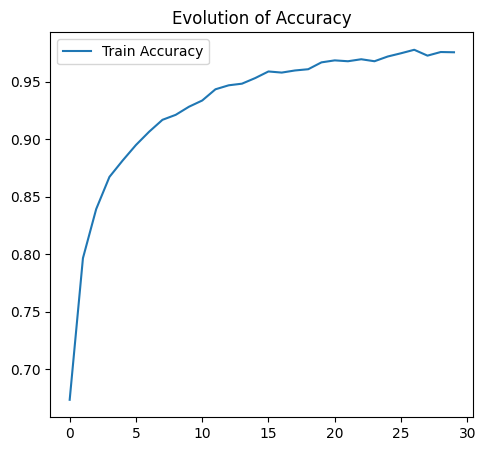

In [18]:
# --- 6. COURBES D'ENTRAÎNEMENT ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title("Evolution of Accuracy")
plt.legend()


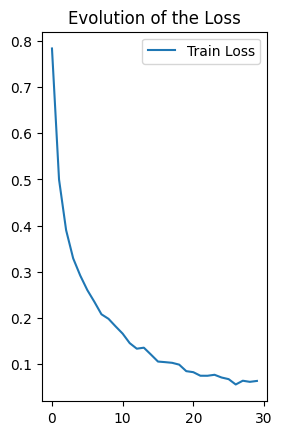

In [19]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Evolution of the Loss')
plt.legend()
plt.show()